# Sesión 1 — Fundamentos de ML y Regresión

**Maestría en Ciencia de Datos y Analítica — EAFIT**

## Objetivos de aprendizaje

Al finalizar esta sesión el estudiante estará en capacidad de:

- Explicar la relación entre Inteligencia Artificial, Machine Learning y
  Deep Learning, y describir el pipeline general de un proyecto de ML.
- Diferenciar el aprendizaje supervisado del no supervisado.
- Describir la metodología general de un proyecto de aprendizaje
  supervisado, incluyendo la partición de datos en train/validation/test
  y por qué es indispensable para una evaluación justa.
- Formular el problema de regresión como la estimación de una función
  $f$ que relaciona variables de entrada $X$ con una variable objetivo
  $Y$ numérica y continua.
- Calcular e interpretar las métricas de desempeño más usadas en
  regresión: MAE, MSE, RMSE, $R^2$ y MAPE.
- Entrenar y comparar modelos de regresión (Regresión Lineal y Random
  Forest) sobre un dataset real, usando `scikit-learn`.

## Dataset de la clase

Usaremos **Ames Housing**, un dataset real de precios de vivienda en
Ames, Iowa (EE. UU.), muy usado para enseñar regresión porque combina
variables numéricas y categóricas, y tiene una variable objetivo
continua clara: el precio de venta.

## 1. Introducción al Machine Learning

### 1.1 IA → ML → Deep Learning

Estos tres términos se usan muchas veces como sinónimos, pero forman
una jerarquía de contención:

- **Inteligencia Artificial (IA)**: el campo más amplio; cualquier
  técnica que permita a una máquina imitar comportamiento inteligente
  (razonar, planear, percibir, decidir).
- **Machine Learning (ML)**: un subconjunto de la IA. En vez de
  programar reglas explícitas, el sistema **aprende patrones a partir
  de datos** para tomar decisiones o hacer predicciones.
- **Deep Learning (DL)**: un subconjunto del ML que usa redes
  neuronales con varias capas (arquitecturas "profundas") para aprender
  representaciones cada vez más abstractas de los datos, especialmente
  útil en dominios como visión por computador, texto y audio.

```
IA  ⊃  Machine Learning  ⊃  Deep Learning
```

### 1.2 Aplicaciones de ML

ML ya está presente en tareas muy cotidianas:

- Recomendación de contenido (Netflix, Spotify, e-commerce).
- Detección de fraude en transacciones financieras.
- Diagnóstico asistido en imágenes médicas.
- Mantenimiento predictivo en plantas industriales.
- Precificación dinámica y estimación de valor de activos (p. ej.
  precios de vivienda, el problema que usaremos hoy).
- Modelos de riesgo crediticio y scoring.

### 1.3 Pipeline de un proyecto de ML

Un proyecto de ML no es solo "entrenar un modelo": es un proceso con
varias etapas, típicamente iterativo (no estrictamente lineal):

1. **Data Collection** — identificar y recolectar las fuentes de datos
   relevantes para el problema de negocio.
2. **Data Cleaning and Preparation** — tratar valores faltantes,
   errores, outliers, formatos inconsistentes; construir variables
   (feature engineering).
3. **Modeling and Optimization** — seleccionar y entrenar modelos,
   ajustar hiperparámetros.
4. **Model Evaluation** — medir el desempeño con métricas apropiadas,
   sobre datos que el modelo no vio en entrenamiento.
5. **Model Deployment and Monitoring** — poner el modelo en producción
   y monitorear su desempeño en el tiempo (los datos del mundo real
   cambian, y el modelo puede degradarse).

Hoy nos enfocamos principalmente en las etapas 2, 3 y 4 para un
problema de regresión.

## 2. Aprendizaje supervisado vs. no supervisado

- **Aprendizaje no supervisado**: solo tenemos variables de entrada
  $X$, **no hay una variable objetivo conocida**. El objetivo es
  descubrir estructura o patrones en los datos (por ejemplo, agrupar
  clientes similares con *clustering*, o reducir dimensionalidad con
  PCA). No hay una "respuesta correcta" contra la cual comparar.

- **Aprendizaje supervisado**: tenemos variables de entrada $X$ **y**
  una variable objetivo conocida $Y$ para cada observación de
  entrenamiento. El modelo aprende la relación entre $X$ y $Y$ para
  luego predecir $Y$ en observaciones nuevas donde no la conocemos.

  - Si $Y$ es **numérica y continua** → problema de **regresión**
    (el tema de hoy: precio de una vivienda, temperatura, demanda,
    etc.).
  - Si $Y$ es **categórica** → problema de **clasificación** (lo
    veremos en una sesión futura): ¿el cliente se va a fugar sí/no?,
    ¿la transacción es fraude sí/no?

En el dataset de Ames Housing, `price` es una variable numérica y
continua conocida para cada casa del histórico, así que este es un
problema **supervisado de regresión**.

## 3. Metodología del aprendizaje supervisado

Un proyecto de aprendizaje supervisado sigue, en términos generales,
esta secuencia:

1. **Análisis exploratorio (EDA)** — entender la forma de los datos:
   distribuciones, relaciones entre variables, valores atípicos.
2. **Calidad de datos** — identificar y tratar valores faltantes,
   inconsistencias, duplicados, errores de captura.
3. **Definición de métricas** — decidir *antes* de modelar cómo se va
   a medir el éxito (por ejemplo, RMSE para regresión). Esto evita
   elegir la métrica que más le convenga al modelo *después* de verlo.
4. **Partición del conjunto de datos** — separar en train / validation
   / test (lo vemos en detalle en la siguiente sección).
5. **Selección de variables** — decidir qué variables de entrada usar,
   descartando las irrelevantes, redundantes o que generan fuga de
   información (*data leakage*).
6. **Ajuste y selección de modelos** — entrenar distintos algoritmos
   y/o configuraciones, comparándolos de forma justa.
7. **Estandarización** — muchos algoritmos (regresión regularizada,
   KNN, redes neuronales, SVM) son sensibles a la escala de las
   variables; conviene estandarizar o normalizar.
8. **Evaluación de modelos** — medir el desempeño final sobre datos que
   el modelo nunca vio, usando las métricas definidas en el paso 3.

Vamos a recorrer esta metodología aplicada al dataset de Ames Housing.

## 4. Cargando y explorando el dataset Ames Housing

Cargamos el dataset directamente desde una URL pública (sin descargar
archivos a mano).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/openintro/ames.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(2930, 83)


,rownames,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,...,Screen.Porch,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition
0,1,1,526301100,1656,215000,20,RL,141.0,31770,Pave,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,2,526350040,896,105000,20,RH,80.0,11622,Pave,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,3,526351010,1329,172000,20,RL,81.0,14267,Pave,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,4,526353030,2110,244000,20,RL,93.0,11160,Pave,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,5,527105010,1629,189900,60,RL,74.0,13830,Pave,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


Confirmamos el nombre real de la variable objetivo (precio de venta)
inspeccionando las columnas, en vez de asumirlo:

In [2]:
precio_candidatas = [c for c in df.columns if "price" in c.lower()]
print("Columnas candidatas a variable objetivo:", precio_candidatas)

target_col = "price"
df[target_col].describe()

Columnas candidatas a variable objetivo: ['price']


count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: price, dtype: float64

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 83 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rownames         2930 non-null   int64  
 1   Order            2930 non-null   int64  
 2   PID              2930 non-null   int64  
 3   area             2930 non-null   int64  
 4   price            2930 non-null   int64  
 5   MS.SubClass      2930 non-null   int64  
 6   MS.Zoning        2930 non-null   str    
 7   Lot.Frontage     2440 non-null   float64
 8   Lot.Area         2930 non-null   int64  
 9   Street           2930 non-null   str    
 10  Alley            198 non-null    str    
 11  Lot.Shape        2930 non-null   str    
 12  Land.Contour     2930 non-null   str    
 13  Utilities        2930 non-null   str    
 14  Lot.Config       2930 non-null   str    
 15  Land.Slope       2930 non-null   str    
 16  Neighborhood     2930 non-null   str    
 17  Condition.1      2930 non

### Calidad de datos: valores nulos

El dataset original tiene 83 columnas, muchas categóricas con bastantes
nulos (por ejemplo `Pool.QC` o `Alley`, donde el nulo en realidad
significa "no tiene piscina" / "no tiene callejón"). Para esta primera
sesión trabajaremos con un subconjunto de variables **numéricas** con
pocos o ningún valor faltante, y dejamos el tratamiento más cuidadoso
de variables categóricas y nulos para sesiones futuras.

In [4]:
nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0].head(15)

Pool.QC           2917
Misc.Feature      2824
Alley             2732
Fence             2358
Mas.Vnr.Type      1775
Fireplace.Qu      1422
Lot.Frontage       490
Garage.Yr.Blt      159
Garage.Finish      159
Garage.Qual        159
Garage.Cond        159
Garage.Type        157
Bsmt.Exposure       83
BsmtFin.Type.2      81
BsmtFin.Type.1      80
dtype: int64

In [5]:
features = [
    "area",            # área habitable
    "Overall.Qual",    # calidad general de materiales y acabados (1-10)
    "Year.Built",       # año de construcción
    "Total.Bsmt.SF",    # área total de sótano
    "Garage.Cars",      # capacidad del garaje en autos
    "Full.Bath",        # baños completos
    "Bedroom.AbvGr",    # habitaciones sobre el nivel del suelo
    "Lot.Area",          # área del lote
    "TotRms.AbvGrd",     # total de habitaciones sobre el nivel del suelo
]

datos = df[features + [target_col]].dropna().reset_index(drop=True)
print("Filas antes de eliminar nulos en las variables elegidas:", len(df))
print("Filas después:", len(datos))
datos.describe()

Filas antes de eliminar nulos en las variables elegidas: 2930
Filas después: 2928


,area,Overall.Qual,Year.Built,Total.Bsmt.SF,Garage.Cars,Full.Bath,Bedroom.AbvGr,Lot.Area,TotRms.AbvGrd,price
count,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000
mean,1499.784495,6.095970,1971.381489,1051.680328,1.767077,1.566598,2.854508,10149.730533,6.443989,180841.033811
std,505.522007,1.410831,30.238845,440.675942,0.760564,0.552972,0.827859,7882.299902,1.572832,79889.904415
min,334.000000,1.000000,1872.000000,0.000000,0.000000,0.000000,0.000000,1300.000000,2.000000,12789.000000
25%,1126.000000,5.000000,1954.000000,793.000000,1.000000,1.000000,2.000000,7440.750000,5.000000,129500.000000
50%,1442.000000,6.000000,1973.000000,990.000000,2.000000,2.000000,3.000000,9444.500000,6.000000,160000.000000
75%,1742.250000,7.000000,2001.000000,1302.000000,2.000000,2.000000,3.000000,11556.000000,7.000000,213500.000000
max,5642.000000,10.000000,2010.000000,6110.000000,5.000000,4.000000,8.000000,215245.000000,15.000000,755000.000000


### Distribución de la variable objetivo

Antes de modelar conviene mirar cómo se distribuye `price`: si está muy
sesgada, algunos modelos (y algunas métricas) se ven afectados por los
valores extremos.

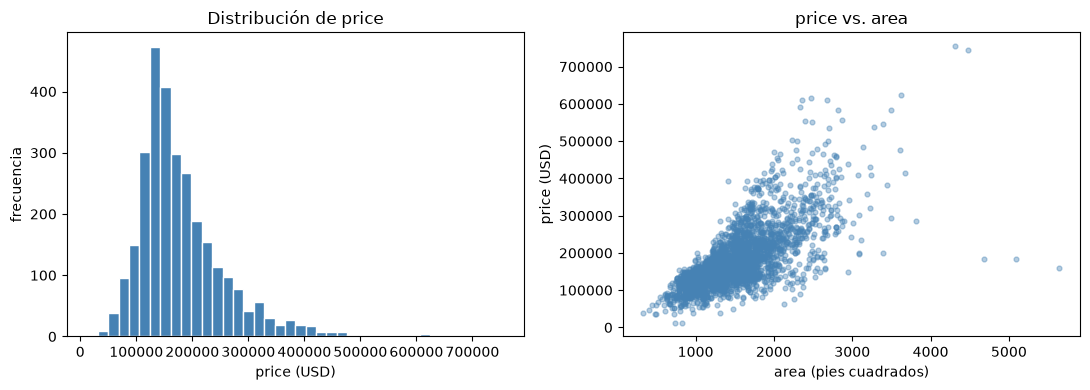

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(datos[target_col], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Distribución de price")
axes[0].set_xlabel("price (USD)")
axes[0].set_ylabel("frecuencia")

axes[1].scatter(datos["area"], datos[target_col], alpha=0.4, s=12, color="steelblue")
axes[1].set_title("price vs. area")
axes[1].set_xlabel("area (pies cuadrados)")
axes[1].set_ylabel("price (USD)")

plt.tight_layout()
plt.show()

La distribución de `price` tiene cola derecha (algunas casas muy
costosas): esto es típico en variables de precio, y es relevante porque
las métricas basadas en errores al cuadrado (MSE/RMSE) van a ser más
sensibles a esos valores extremos que MAE, como veremos más adelante.

## 5. Partición de datos: train / validation / test

Para evaluar un modelo de forma **justa** necesitamos medir su
desempeño sobre datos que **nunca vio durante el entrenamiento**. Si
evaluamos con los mismos datos que usamos para ajustar el modelo,
corremos el riesgo de una **fuga de información** (*data leakage*): el
modelo "memoriza" en vez de "generalizar", y la métrica que reportamos
es demasiado optimista frente a lo que pasará con datos nuevos en
producción.

Por eso partimos los datos en (al menos) tres conjuntos:

- **Train**: se usa para *ajustar* los parámetros del modelo.
- **Validation**: se usa para *comparar modelos o configuraciones*
  (por ejemplo, elegir hiperparámetros) sin tocar el test.
- **Test**: se usa **una sola vez**, al final, para estimar cómo se
  comportará el modelo con datos nuevos del mundo real.

Una partición típica es 60/20/20 o 70/15/15, dependiendo del tamaño del
dataset. Hoy usaremos 60% train, 20% validation, 20% test.

In [7]:
X = datos[features]
y = datos[target_col]

# Primero separamos test (20%) del resto (80%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Del 80% restante, separamos validation (25% de ese 80% = 20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE
)

print("Train:     ", X_train.shape)
print("Validation:", X_val.shape)
print("Test:      ", X_test.shape)

Train:      (1756, 9)
Validation: (586, 9)
Test:       (586, 9)


## 6. El problema de regresión

En un problema de regresión asumimos que existe una relación (no
necesariamente lineal) entre las variables de entrada $X$ y la variable
objetivo $Y$, de la forma:

$$Y = f(X) + \varepsilon$$

donde:

- $f$ es una función **desconocida** que describe la relación
  sistemática entre $X$ y $Y$.
- $\varepsilon$ es un término de error aleatorio, con media cero,
  independiente de $X$, que recoge todo lo que $X$ no puede explicar.

El objetivo del aprendizaje supervisado en regresión es **estimar
$f$** a partir de los datos observados, obteniendo una función
$\hat{f}$ tal que $\hat{Y} = \hat{f}(X)$ sea una buena aproximación de
$Y$.

### ¿Para qué queremos estimar $f$?

1. **Predicción**: dado un nuevo punto $X$ (una casa que no está en el
   histórico), predecir $\hat{Y}$ (su precio esperado).
2. **Entender la importancia de las variables**: ¿qué variables de
   entrada son las que más influyen sobre $Y$? (por ejemplo, ¿el área
   pesa más que el año de construcción?).
3. **Interpretar cómo cada componente de $X$ afecta a $Y$**: por
   ejemplo, ¿cuánto sube el precio esperado por cada punto adicional de
   calidad general (`Overall.Qual`), manteniendo lo demás constante?

### Complejidad del modelo (idea intuitiva)

Al estimar $\hat{f}$ podemos elegir modelos con distinta
**flexibilidad**:

- Un modelo **poco flexible** (por ejemplo, una regresión lineal
  simple) puede no capturar relaciones complejas o no lineales entre
  $X$ y $Y$: se queda "corto".
- Un modelo **muy flexible** (por ejemplo, un árbol muy profundo) puede
  ajustarse demasiado a las particularidades de los datos de
  entrenamiento, incluyendo el ruido $\varepsilon$, y no generalizar
  bien a datos nuevos.
- Existe un punto "intermedio" donde el modelo captura la señal real de
  $f$ sin sobreajustarse al ruido.

Esta tensión se llama el **balance sesgo-varianza**, y la
estudiaremos en profundidad en la Sesión 2. Por ahora, la vamos a
**ilustrar de forma intuitiva** comparando dos modelos: uno poco
flexible (Regresión Lineal) y uno más flexible (Random Forest).

### Modelo 1: Regresión Lineal (poco flexible)

La regresión lineal asume que $f$ tiene la forma:

$$\hat{Y} = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p$$

Es un modelo simple, fácil de interpretar (cada $\beta_i$ nos dice
cuánto cambia $\hat{Y}$ por cada unidad de $X_i$, manteniendo lo demás
constante), pero limitado a relaciones lineales.

In [8]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

coeficientes = pd.Series(modelo_lineal.coef_, index=features).sort_values(key=abs, ascending=False)
print("Intercepto:", modelo_lineal.intercept_)
coeficientes

Intercepto: -848978.0781948576


Overall.Qual     20477.315870
Garage.Cars      11911.346387
Bedroom.AbvGr    -7730.874099
Full.Bath        -5835.398324
TotRms.AbvGrd     1459.270459
Year.Built         402.712111
area                53.237548
Total.Bsmt.SF       22.645315
Lot.Area             0.689581
dtype: float64

### Modelo 2: Random Forest (más flexible)

Un Random Forest es un conjunto (*ensemble*) de árboles de decisión que
puede capturar relaciones no lineales e interacciones entre variables
sin que tengamos que especificarlas manualmente. Es un modelo mucho más
flexible que la regresión lineal.

In [9]:
modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
modelo_rf.fit(X_train, y_train)

importancias = pd.Series(modelo_rf.feature_importances_, index=features).sort_values(ascending=False)
importancias

Overall.Qual     0.631234
area             0.152343
Total.Bsmt.SF    0.071976
Lot.Area         0.051427
Year.Built       0.043900
Full.Bath        0.017244
Garage.Cars      0.015915
TotRms.AbvGrd    0.008016
Bedroom.AbvGr    0.007945
dtype: float64

## 7. Métricas de desempeño para regresión

Sea $y_i$ el valor real, $\hat{y}_i$ el valor predicho, y $n$ el número
de observaciones.

### MAE — Mean Absolute Error

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Promedio del error absoluto, en las mismas unidades que $Y$. Es
**robusto a outliers**: un error muy grande pesa proporcionalmente a su
tamaño, no al cuadrado.

### MSE — Mean Squared Error

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Promedio del error al cuadrado. Al elevar al cuadrado, **penaliza más
los errores grandes** que los pequeños, pero queda en unidades al
cuadrado (difícil de interpretar directamente).

### RMSE — Root Mean Squared Error

$$\text{RMSE} = \sqrt{\text{MSE}}$$

Es la raíz del MSE, así que vuelve a las unidades originales de $Y$.
Sigue **penalizando más los errores grandes** que el MAE, y es de las
métricas más usadas en la práctica (y la que usaremos para calificar el
assignment de esta sesión).

### $R^2$ — Coeficiente de determinación

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

Mide la **proporción de la varianza de $Y$ explicada por el modelo**,
comparado contra un modelo trivial que siempre predice el promedio
$\bar{y}$. $R^2 = 1$ es ajuste perfecto; $R^2 = 0$ equivale a predecir
siempre el promedio; puede ser negativo si el modelo es peor que
predecir el promedio.

### MAPE — Mean Absolute Percentage Error

$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

Expresa el error como **porcentaje** del valor real, lo cual facilita
la interpretación de negocio ("el modelo se equivoca en promedio un
8%"). Su gran limitación: **falla (se dispara o es indefinido) cuando
$y_i$ está cerca de cero**, porque se divide por $y_i$.

### ¿Cuál usar?

No hay una única respuesta correcta; depende del problema:

- Si hay outliers y no quieres que dominen la métrica → **MAE**.
- Si los errores grandes son especialmente costosos en tu problema de
  negocio → **MSE/RMSE**.
- Si quieres comunicar qué tan bien explicas la varianza total →
  **$R^2$**.
- Si quieres comunicar el error en términos relativos/porcentuales, y
  tu variable objetivo nunca está cerca de cero → **MAPE**.

In [10]:
def calcular_metricas(y_true, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return pd.Series(
        {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2, "MAPE": mape},
        name=nombre_modelo,
    )

pred_lineal_val = modelo_lineal.predict(X_val)
pred_rf_val = modelo_rf.predict(X_val)

resultados_val = pd.concat(
    [
        calcular_metricas(y_val, pred_lineal_val, "Regresión Lineal"),
        calcular_metricas(y_val, pred_rf_val, "Random Forest"),
    ],
    axis=1,
)
resultados_val.round(2)

,Regresión Lineal,Random Forest
MAE,2.279502e+04,1.837928e+04
MSE,1.165316e+09,9.134199e+08
RMSE,3.413672e+04,3.022284e+04
R2,8.200000e-01,8.600000e-01
MAPE,1.300000e-01,1.000000e-01


**Lectura de resultados (validation):**

- El Random Forest, al ser más flexible, generalmente logra un
  MAE/RMSE menor y un $R^2$ mayor que la Regresión Lineal en este
  conjunto de validación: captura relaciones no lineales que la
  regresión lineal no puede representar.
- Esto **no** significa que "más flexible siempre es mejor": con pocos
  datos o muchas variables, un modelo muy flexible puede sobreajustar
  (memorizar el ruido de train) y desempeñarse peor en datos nuevos.
  Este balance (sesgo-varianza) es el tema central de la Sesión 2.
- Nota que evaluamos ambos modelos sobre **validation**, no sobre
  **test**: el test lo reservamos para la evaluación final, una vez
  hayamos decidido qué modelo usar.

### Evaluación final sobre el conjunto de test

Supongamos que, tras comparar en validation, decidimos quedarnos con el
Random Forest. La evaluación **final**, la que reportaríamos como el
desempeño esperado del modelo en producción, se hace sobre **test**
(datos que el modelo no vio ni en entrenamiento ni en la selección de
modelo).

In [11]:
pred_rf_test = modelo_rf.predict(X_test)
metricas_test = calcular_metricas(y_test, pred_rf_test, "Random Forest (test)")
metricas_test.round(2)

MAE     1.820238e+04
MSE     9.179998e+08
RMSE    3.029851e+04
R2      8.900000e-01
MAPE    1.000000e-01
Name: Random Forest (test), dtype: float64

## Ejercicios de práctica

Los siguientes ejercicios son progresivos. Intenta resolver cada uno
antes de mirar la celda de solución.

### Ejercicio 1 — Efecto de los outliers en las métricas

El dataset tiene casas muy costosas (outliers en `price`) y casas con
áreas atípicamente grandes. Filtra el conjunto de datos eliminando el
1% de observaciones con `price` más alto, vuelve a partir train/val/test
con la misma semilla, reentrena la Regresión Lineal, y compara las
métricas MAE, RMSE y $R^2$ antes y después de filtrar. ¿Qué métrica
cambia más? ¿Por qué?

In [12]:
# TODO: filtra el 1% de precios más altos, reentrena la regresión lineal
# y compara MAE/RMSE/R2 contra el modelo original (sin filtrar).


#### Solución — Ejercicio 1

In [13]:
umbral = datos[target_col].quantile(0.99)
datos_sin_outliers = datos[datos[target_col] <= umbral].reset_index(drop=True)
print(f"Filas originales: {len(datos)} | Filas sin el 1% más caro: {len(datos_sin_outliers)}")

X_o = datos_sin_outliers[features]
y_o = datos_sin_outliers[target_col]

X_train_val_o, X_test_o, y_train_val_o, y_test_o = train_test_split(
    X_o, y_o, test_size=0.2, random_state=RANDOM_STATE
)
X_train_o, X_val_o, y_train_o, y_val_o = train_test_split(
    X_train_val_o, y_train_val_o, test_size=0.25, random_state=RANDOM_STATE
)

modelo_lineal_o = LinearRegression()
modelo_lineal_o.fit(X_train_o, y_train_o)
pred_o = modelo_lineal_o.predict(X_val_o)

comparacion_outliers = pd.concat(
    [
        calcular_metricas(y_val, pred_lineal_val, "Con outliers"),
        calcular_metricas(y_val_o, pred_o, "Sin el 1% más caro"),
    ],
    axis=1,
)
comparacion_outliers.round(2)

Filas originales: 2928 | Filas sin el 1% más caro: 2898


,Con outliers,Sin el 1% más caro
MAE,2.279502e+04,2.221260e+04
MSE,1.165316e+09,1.092490e+09
RMSE,3.413672e+04,3.305284e+04
R2,8.200000e-01,7.800000e-01
MAPE,1.300000e-01,1.300000e-01


**Discusión:** al quitar el 1% de precios más altos, el RMSE y el MSE
suelen bajar de forma más marcada que el MAE, porque esas observaciones
extremas contribuían errores muy grandes que, al elevarse al cuadrado,
dominaban el promedio. El MAE también puede bajar, pero proporcionalmente
menos. Esto confirma que RMSE/MSE son más sensibles a outliers que MAE.

### Ejercicio 2 — Comparar un subconjunto distinto de variables

Entrena una nueva Regresión Lineal usando **solo** estas variables:
`area`, `Year.Built` y `Lot.Area` (sin `Overall.Qual`, `Total.Bsmt.SF`,
etc.). Compara el $R^2$ en validation contra el modelo original (con
las 9 variables). ¿Qué te dice esta comparación sobre la importancia de
`Overall.Qual` para explicar el precio?

In [14]:
# TODO: entrena una LinearRegression con el subconjunto de variables
# ['area', 'Year.Built', 'Lot.Area'] y compara su R2 en validation
# contra el modelo con las 9 variables originales.


#### Solución — Ejercicio 2

In [15]:
features_reducidas = ["area", "Year.Built", "Lot.Area"]

modelo_reducido = LinearRegression()
modelo_reducido.fit(X_train[features_reducidas], y_train)
pred_reducido_val = modelo_reducido.predict(X_val[features_reducidas])

comparacion_features = pd.concat(
    [
        calcular_metricas(y_val, pred_lineal_val, "9 variables"),
        calcular_metricas(y_val, pred_reducido_val, "3 variables (sin Overall.Qual)"),
    ],
    axis=1,
)
comparacion_features.round(2)

,9 variables,3 variables (sin Overall.Qual)
MAE,2.279502e+04,3.081190e+04
MSE,1.165316e+09,2.054721e+09
RMSE,3.413672e+04,4.532903e+04
R2,8.200000e-01,6.900000e-01
MAPE,1.300000e-01,1.700000e-01


**Discusión:** el $R^2$ del modelo reducido suele ser notablemente más
bajo que el del modelo con 9 variables. Esto sugiere que `Overall.Qual`
(y las demás variables removidas) aportan información valiosa que
`area`, `Year.Built` y `Lot.Area` por sí solas no capturan — consistente
con que `Overall.Qual` aparecía entre los coeficientes/importancias más
altos en las secciones anteriores.

### Ejercicio 3 — Gráfico de residuales

Los **residuales** son la diferencia entre el valor real y el
predicho: $e_i = y_i - \hat{y}_i$. Grafica los residuales del modelo de
Regresión Lineal (eje X: valor predicho $\hat{y}_i$, eje Y: residual
$e_i$) sobre el conjunto de validation, y traza una línea horizontal en
cero. ¿Qué patrón observas? ¿Los residuales se ven distribuidos de
forma aleatoria alrededor de cero, o hay una tendencia?

In [16]:
# TODO: grafica los residuales (y_val - pred_lineal_val) contra
# pred_lineal_val, con una línea horizontal en 0. Interpreta el patrón.


#### Solución — Ejercicio 3

<>:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/var/folders/65/mz3st45n0jz6qz9cp_f5cr9m0000gn/T/ipykernel_16186/337522072.py:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.xlabel("Valor predicho ($\hat{y}$)")
/var/folders/65/mz3st45n0jz6qz9cp_f5cr9m0000gn/T/ipykernel_16186/337522072.py:7: SyntaxWarning: "\h" is an invalid es

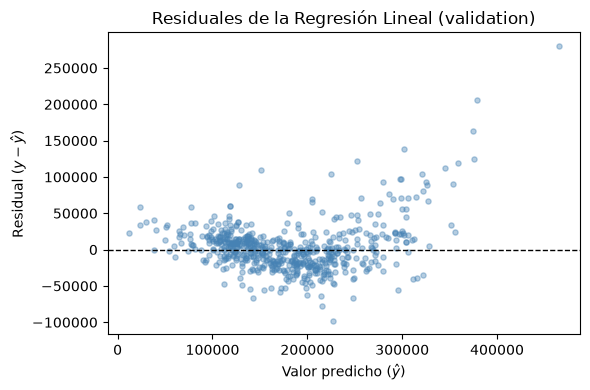

In [17]:
residuales = y_val.values - pred_lineal_val

plt.figure(figsize=(6, 4))
plt.scatter(pred_lineal_val, residuales, alpha=0.4, s=14, color="steelblue")
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.xlabel(r"Valor predicho ($\hat{y}$)")
plt.ylabel(r"Residual ($y - \hat{y}$)")
plt.title("Residuales de la Regresión Lineal (validation)")
plt.tight_layout()
plt.show()

**Discusión:** en un modelo bien especificado esperaríamos ver los
residuales dispersos aleatoriamente alrededor de cero, sin patrón. En
este caso es común observar que la dispersión de los residuales
**aumenta** a medida que el precio predicho aumenta (forma de "embudo"
o "cono"): esto se llama **heterocedasticidad**, e indica que el
modelo lineal simple no captura del todo bien el comportamiento de las
casas más costosas. También pueden aparecer residuales sistemáticamente
positivos o negativos en ciertos rangos, señal de que la relación real
no es puramente lineal — otra pista de por qué el Random Forest
(más flexible) obtenía mejores métricas.

## Resumen de conceptos clave

- **IA ⊃ ML ⊃ Deep Learning**: el ML aprende patrones de datos en vez
  de seguir reglas explícitas; el Deep Learning es ML con redes
  neuronales profundas.
- El pipeline de un proyecto de ML incluye: recolección de datos,
  limpieza y preparación, modelado y optimización, evaluación, y
  despliegue con monitoreo.
- **No supervisado**: solo $X$, se buscan patrones. **Supervisado**: $X$
  y $Y$ conocidos; si $Y$ es numérico y continuo, es un problema de
  **regresión**.
- La metodología de un proyecto supervisado sigue, en general: EDA →
  calidad de datos → definición de métricas → partición de datos →
  selección de variables → ajuste/selección de modelos →
  estandarización → evaluación.
- Partir los datos en **train/validation/test** es indispensable para
  evitar fuga de información y obtener una estimación honesta del
  desempeño del modelo en datos nuevos.
- En regresión, buscamos estimar una función $f$ desconocida tal que
  $Y \approx f(X)$; la complejidad del modelo (flexibilidad) es una
  decisión clave, que profundizaremos con el balance sesgo-varianza en
  la Sesión 2.
- Métricas de regresión: **MAE** (robusto a outliers), **MSE/RMSE**
  (penalizan errores grandes), **$R^2$** (proporción de varianza
  explicada), **MAPE** (error porcentual, falla cerca de cero). Ninguna
  es "la mejor" en absoluto: la elección depende del problema.

### Próxima sesión

En la Sesión 2 profundizaremos en el balance **sesgo-varianza**,
sobreajuste/subajuste, y técnicas de regularización y validación
cruzada.